# AI Classification Results - Exploratory Data Analysis (EDA)

This notebook provides a detailed overview of the Llama-based classification results for the YouTube transcript dataset.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import numpy as np

# Setting aesthetic style for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load data
df = pd.read_parquet('data/output/output_classification.parquet')

# Basic Info
print(f"Total rows processed: {len(df)}")
df.head()

Total rows processed: 4561


,Unnamed: 0,video_id,transcript,language,channel_id,title,publishedAt,viewCount,likeCount,duration,summary,keywords,is_ai_related,is_ai_generated_content,topics,conf_total,conf_rationale,conf_classification,raw_output
0,0,-0hVuPzK38A,Charles Schwab is the largest publicly traded ...,en,UCvJJ_dzjViJCoLf5uKUTwoA,Why Charles Schwab Became A Financial ‘Superma...,2023-06-17T16:00:00Z,385736.0,4457.0,PT11M28S,Charles Schwab is the largest publicly traded ...,"[Charles Schwab, brokerage, financial services...",False,False,"[business/money, jobs]",0.749066,0.679397,0.0,NaN
1,1,-1EZaW664Hg,[Music] thank you,en,UCrM7B7SL_g1edFOnmj-SDKg,Our anchor Ed Ludlow ran his picture through #...,2022-12-09T23:44:46Z,1754.0,NaN,PT15S,The transcript is too short to provide a meani...,[],False,False,[],0.694271,0.641720,0.0,NaN
2,2,-2WUW2oiAwM,FOUNDING -- FOUNDER AND CEO EDO LIBERTY JOINS ...,en,UCrM7B7SL_g1edFOnmj-SDKg,Pinecone and the Rise of Vector Databases,2023-05-01T18:53:04Z,8710.0,124.0,PT6M35S,"Pinecone, a company providing long-term memory...","[Pinecone, AI models, long-term memory, halluc...",True,False,"[AI models, investment in AI, data accessibility]",0.780330,0.689830,0.0,NaN
3,3,-4H1BYfBDxc,I'm here at Shield AI getting an exclusive fir...,en,UCvJJ_dzjViJCoLf5uKUTwoA,How AI drones could be the future of warfare,2025-11-16T17:00:00Z,30028.0,389.0,PT58S,Shield AI is showcasing its autonomous fighter...,"[Shield AI, XBAT, Hivemine, autonomous fighter...",True,False,"[war, robots, AI models]",0.758919,0.652434,0.0,NaN
4,4,-53Yv6aYtL8,"&gt;&gt; FROM THE HEART OF WHERE INNOVATION, M...",en,UCrM7B7SL_g1edFOnmj-SDKg,"Frank McCourt Preps US TikTok Bid, Google's Ne...",2024-05-15T21:08:45Z,10337.0,159.0,PT44M22S,The video discusses the latest developments in...,"[TikTok, Google, Alphabet, Amazon, Tesla, Open...",True,False,"[business, investment in AI, AI models, device...",0.769641,0.651953,0.0,NaN


## 1. AI-Related Content Distribution
How much of our dataset is classified as AI-related?

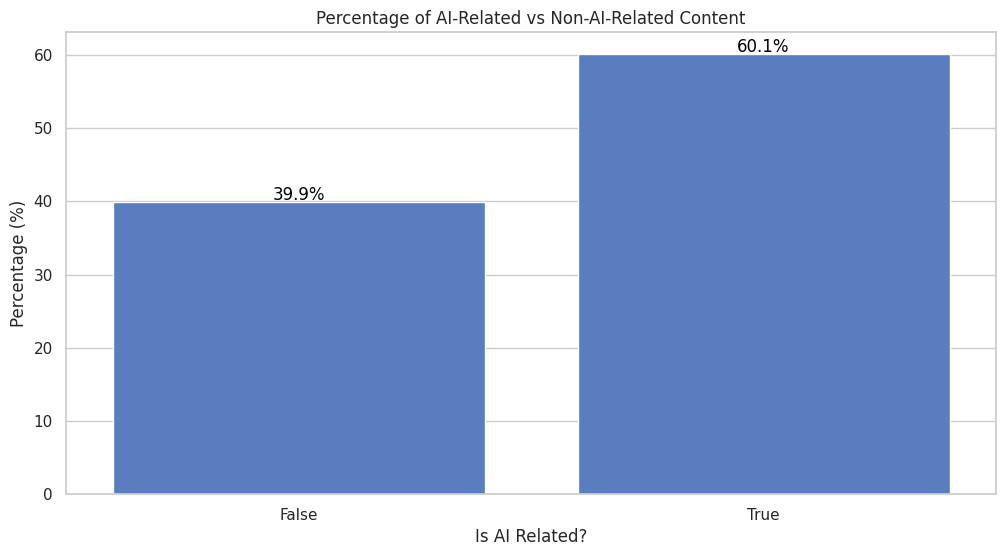

In [27]:
ai_counts = df['is_ai_related'].value_counts(normalize=True) * 100
ax = sns.barplot(x=ai_counts.index, y=ai_counts.values)
plt.title("Percentage of AI-Related vs Non-AI-Related Content")
plt.ylabel("Percentage (%)")
plt.xlabel("Is AI Related?")
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

## 2. Topic Distribution
What are the most frequent topics assigned by the model?

/tmp/ipykernel_1299164/2791516929.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_df, x='Count', y='Topic', palette="viridis")


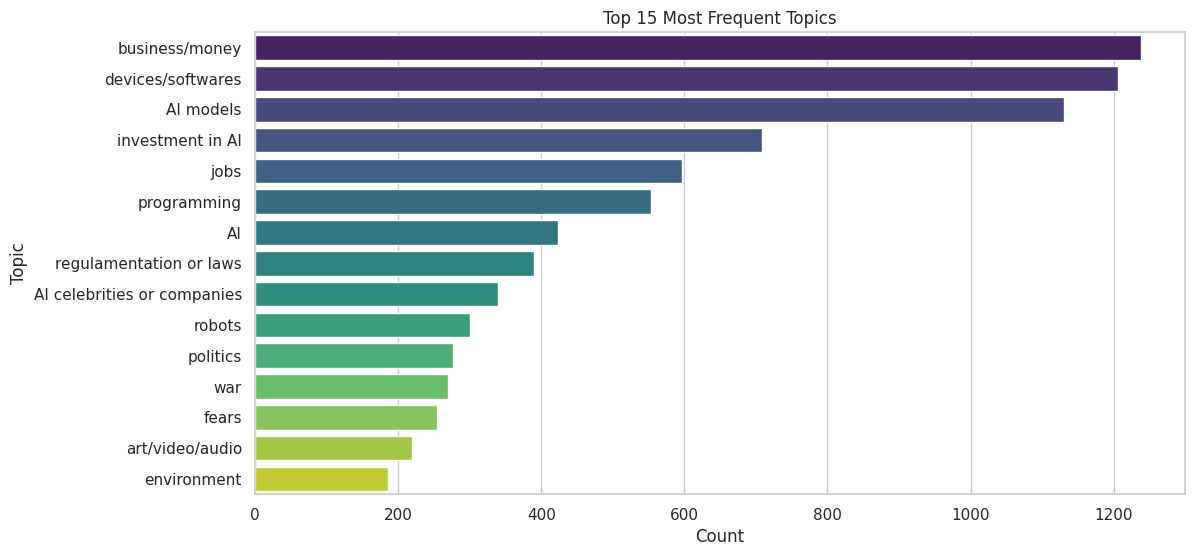

In [34]:
# Topics are stored as lists (or strings that look like lists)
all_topics = []
for t in df['topics'].dropna():
    all_topics.extend(t)

topic_counts = Counter(all_topics).most_common(15)
topic_df = pd.DataFrame(topic_counts, columns=['Topic', 'Count'])

sns.barplot(data=topic_df, x='Count', y='Topic', palette="viridis")
plt.title("Top 15 Most Frequent Topics")
plt.show()

## 3. Confidence Metrics Analysis
Analyzing the model's confidence across different segments of the output.

,conf_total,conf_rationale,conf_classification
count,4561.000000,4561.000000,4561.0
mean,0.771372,0.675880,0.0
std,0.031182,0.041003,0.0
min,0.635329,0.541613,0.0
25%,0.751479,0.649145,0.0
50%,0.771987,0.675687,0.0
75%,0.792104,0.701864,0.0
max,0.890649,0.868547,0.0


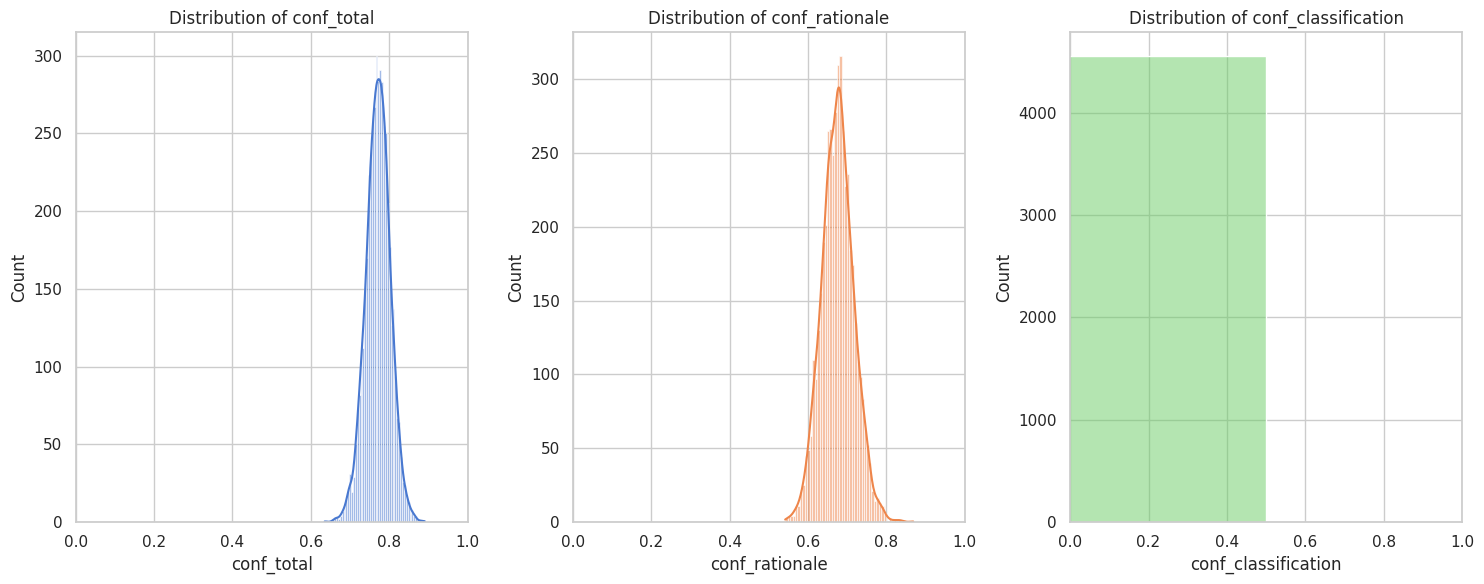

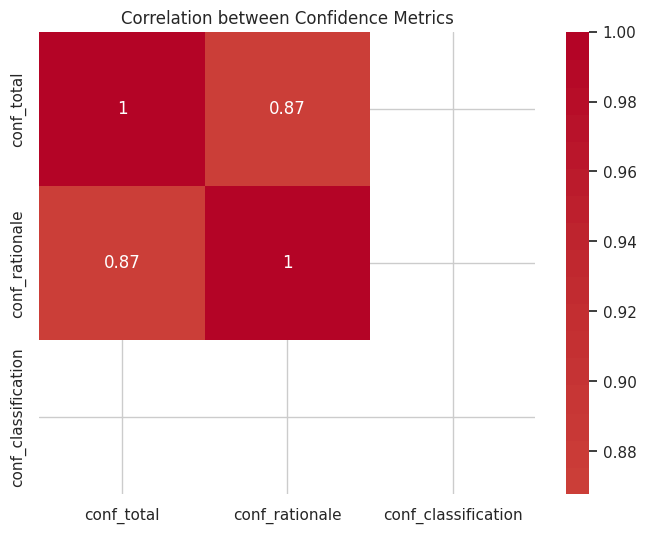

In [ ]:
conf_cols = ['conf_total', 'conf_rationale', 'conf_classification']


# Summary statistics for confidence
display(df[conf_cols].describe())

# Distribution of confidence metrics
plt.figure(figsize=(15, 6))
for i, col in enumerate(conf_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color=sns.color_palette()[i])
    plt.title(f'Distribution of {col}')
    plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Correlation between confidence types
plt.figure(figsize=(8, 6))
sns.heatmap(df[conf_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between Confidence Metrics")
plt.show()

## 4. Keyword Analysis
What keywords are most commonly extracted?

/tmp/ipykernel_1299164/4281479396.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df, x='Count', y='Keyword', palette="magma")


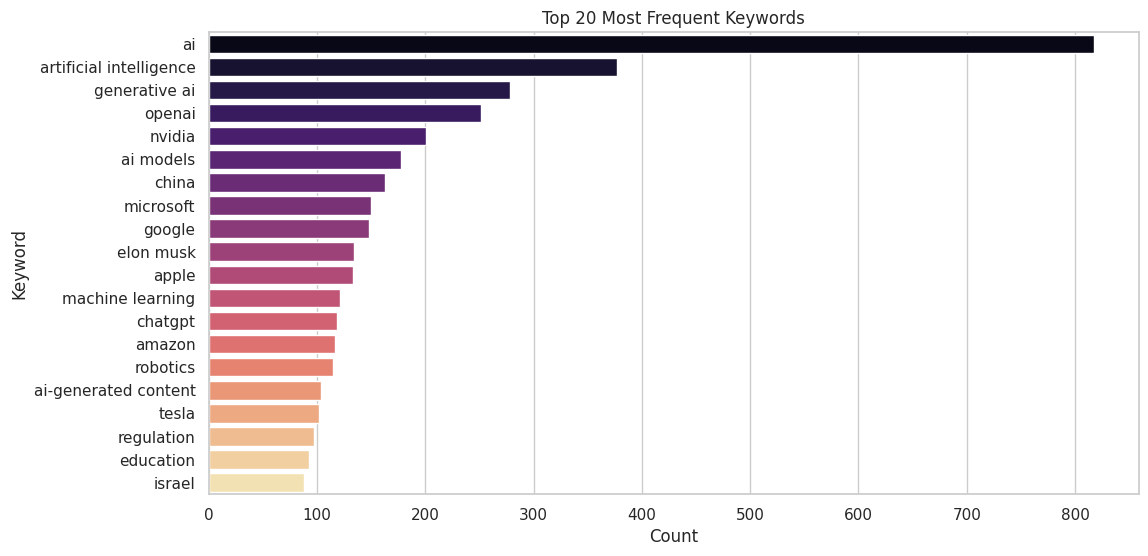

In [33]:
all_keywords = []
for k in df['keywords'].dropna():
    all_keywords.extend([str(item).lower() for item in k])

keyword_counts = Counter(all_keywords).most_common(20)
kw_df = pd.DataFrame(keyword_counts, columns=['Keyword', 'Count'])

sns.barplot(data=kw_df, x='Count', y='Keyword', palette="magma")
plt.title("Top 20 Most Frequent Keywords")
plt.show()

## 5. AI-Related Content over Time
Are we seeing more AI content over time?

/tmp/ipykernel_1299164/2542208107.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_date'] = pd.to_datetime(df['publishedAt']).dt.to_period('M')


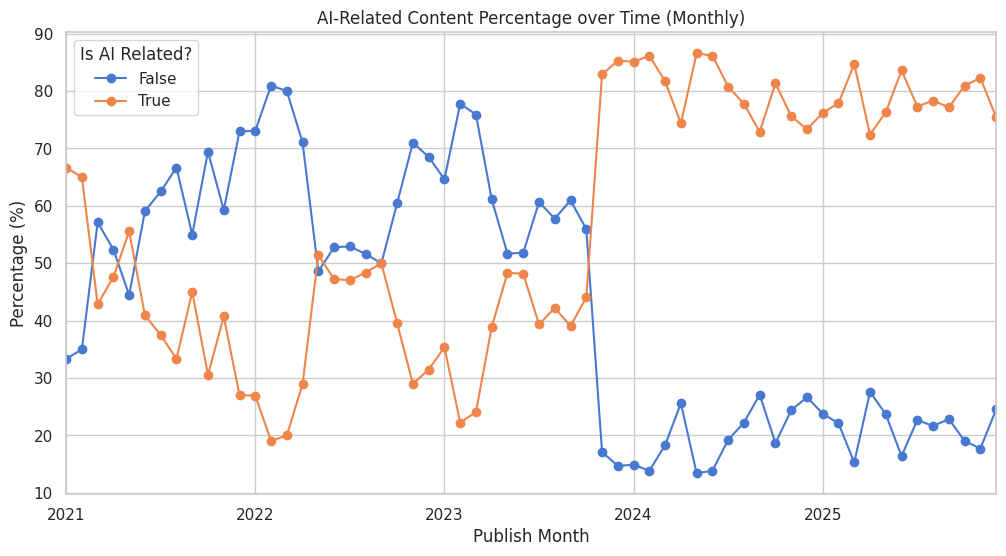

In [31]:
df['published_date'] = pd.to_datetime(df['publishedAt']).dt.to_period('M')
time_data = df.groupby(['published_date', 'is_ai_related']).size().unstack(fill_value=0)
time_data_pct = time_data.div(time_data.sum(axis=1), axis=0) * 100

time_data_pct.plot(kind='line', marker='o')
plt.title("AI-Related Content Percentage over Time (Monthly)")
plt.ylabel("Percentage (%)")
plt.xlabel("Publish Month")
plt.legend(title="Is AI Related?", labels=['False', 'True'])
plt.show()

## 6. Sample View
Let's look at some examples of videos classified as AI-related.

In [32]:
df["url"] = "https://www.youtube.com/watch?v=" + df["video_id"]
ai_samples = df[df['is_ai_related'] == True][['url','title', 'summary', 'topics', 'conf_classification']].sample(min(10, len(df[df['is_ai_related']==True])))
ai_samples

,url,title,summary,topics,conf_classification
1970,https://www.youtube.com/watch?v=IfvrQ-S6i3g,"AI Fuels Tech Selloff, President Trump To Meet...",The transcript discusses the impact of Chinese...,"[investment in AI, AI models, business/money, ...",0.0
832,https://www.youtube.com/watch?v=ABLOfTd0r8Q,We Tested Alexa+ Building an Amazon Fresh Orde...,"Amazon has introduced Alexa Plus, a new servic...","[devices/softwares, AI celebrities or companie...",0.0
910,https://www.youtube.com/watch?v=asp8cit1-dw,Bloomberg Tech Live in San Francisco | Bloombe...,This special edition of Bloomberg Technology f...,"[investment in AI, AI infrastructure, AI appli...",0.0
3340,https://www.youtube.com/watch?v=RYGsGX7WNOM,Google DeepMind’s NEW AI Taught Just Humanoid ...,Google's DeepMind project involves creating hu...,"[robots, AI models, programming]",0.0
2767,https://www.youtube.com/watch?v=o0u-ejfoMgk,Putting Jesus in Times Square? Christian Compa...,The video discusses the dual nature of artific...,"[AI, AI-generated content, AI risks, AI in cre...",0.0
2466,https://www.youtube.com/watch?v=lyuHvrh1qCA,AI-proof your Future | Vijay Gadepally | TEDxN...,The video discusses the impact of Artificial I...,"[AI, jobs, programming]",0.0
1902,https://www.youtube.com/watch?v=hv_uOdqiPJU,NaN,A high-ranking Apple executive's comment cause...,"[business/money, AI celebrities or companies]",0.0
904,https://www.youtube.com/watch?v=aRjI6gxQag0,OpenAI Conference and Big Tech Earnings | Bloo...,OpenAI is hosting its first developer conferen...,"[investment in AI, AI models, business/money]",0.0
3414,https://www.youtube.com/watch?v=SGvDuGSScoo,What's the difference between all of the AI ch...,The video discusses the current landscape of A...,"[devices/softwares, investment in AI, AI models]",0.0
2896,https://www.youtube.com/watch?v=ovkL64yLD2Y,NaN,A device records conversations and uses AI to ...,"[devices/softwares, AI celebrities or companies]",0.0
